<a href="https://colab.research.google.com/github/athfizh/PemMes26_05_Hafizh/blob/main/JS06/JS06-TugasLab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


# **Klasifikasi 2 - Tugas Lab 2**


---

---


# **Persiapan - Mount Google Drive**


---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# folder data praktikum di Google Drive
base_path = '/content/drive/MyDrive/COLLEGE/SEM 5/PEMMES/DATA/images-week06'
print('Lokasi data:', base_path)

Mounted at /content/drive
Lokasi data: /content/drive/MyDrive/COLLEGE/SEM 5/PEMMES/DATA/images-week06


> Data dibaca dari folder `images-week06` di Google Drive, jadi Drive di-mount terlebih dahulu dan lokasinya disimpan pada variabel `base_path`.

---


# **Langkah 1 - Load Data Praktikum 5**


---

In [2]:
from pathlib import Path
import matplotlib.image as mpimg
import cv2
import numpy as np

def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = str(dir).split('/')[-1]
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))

    return img_list

# gabungkan data training dan testing, nanti di-split ulang dengan rasio 80:20
all_img = load_dataset(base_path + '/images/training/') + load_dataset(base_path + '/images/test/')
print('Total citra:', len(all_img))

Total citra: 400


---


# **Langkah 2 - Pra Pengolahan Data**


---

In [3]:
def standarized_input(image):
    # resize to w: 1100, h:600
    return cv2.resize(image, (1100, 600))

def label_encoder(label):
    # day as 1; night as 0
    return 1 if label == 'day' else 0

def preprocess(img_list):
    return [(standarized_input(img), label_encoder(lbl)) for img, lbl in img_list]

all_std_img = preprocess(all_img)
print('Ukuran citra:', all_std_img[0][0].shape)

Ukuran citra: (600, 1100, 3)


---


# **Langkah 3 - Ekstraksi Fitur Histogram**


---

In [4]:
# Fitur: histogram kanal V (brightness) pada ruang warna HSV, dinormalisasi
def extract_histogram(img_list, bins=32):
    fitur = []
    label = []

    for img, lbl in img_list:
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        hist = cv2.calcHist([hsv], [2], None, [bins], [0, 256]).flatten()
        hist = hist / hist.sum()   # normalisasi supaya total = 1

        fitur.append(hist)
        label.append(lbl)

    return np.array(fitur), np.array(label)

X_hist, y_hist = extract_histogram(all_std_img, bins=32)
print('Shape fitur:', X_hist.shape)
print('Shape label:', y_hist.shape)

Shape fitur: (400, 32)
Shape label: (400,)


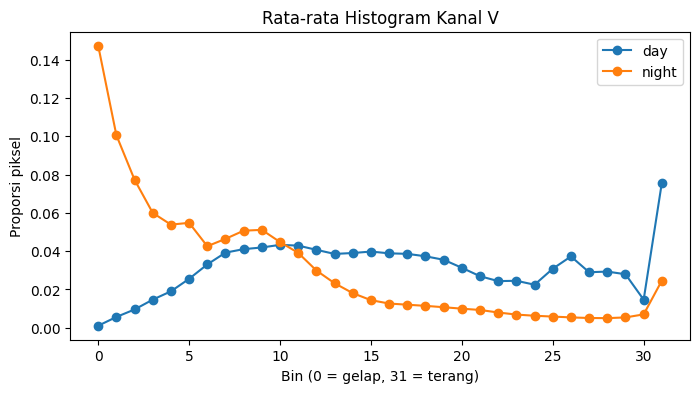

In [5]:
import matplotlib.pyplot as plt

# rata-rata histogram untuk tiap kelas
plt.figure(figsize=(8, 4))
plt.plot(X_hist[y_hist == 1].mean(axis=0), label='day', marker='o')
plt.plot(X_hist[y_hist == 0].mean(axis=0), label='night', marker='o')
plt.title('Rata-rata Histogram Kanal V')
plt.xlabel('Bin (0 = gelap, 31 = terang)')
plt.ylabel('Proporsi piksel')
plt.legend()
plt.show()

> Fitur yang dipakai adalah histogram kanal V (brightness) pada ruang warna HSV sebanyak 32 bin yang sudah dinormalisasi. Pada plot rata-rata histogram, citra malam menumpuk di bin yang gelap (kiri), sedangkan citra siang tersebar ke bin yang lebih terang. Berbeda dengan rata-rata brightness yang hanya berupa satu angka, histogram menyimpan sebaran kecerahan di seluruh piksel sehingga informasinya lebih kaya.

---


# **Langkah 4 - Split Data 80:20**


---

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_hist, y_hist, test_size=0.2, random_state=42, stratify=y_hist)

print('Data training:', X_train.shape)
print('Data testing :', X_test.shape)

Data training: (320, 32)
Data testing : (80, 32)


---


# **Langkah 5 - Model SVM Kernel RBF (Default)**


---

In [7]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

model_default = make_pipeline(StandardScaler(), SVC(kernel='rbf'))
model_default.fit(X_train, y_train)

acc_train = accuracy_score(y_train, model_default.predict(X_train))
acc_test = accuracy_score(y_test, model_default.predict(X_test))
print(f'Akurasi train (C=1, gamma=scale): {acc_train:.4f}')
print(f'Akurasi test  (C=1, gamma=scale): {acc_test:.4f}')

Akurasi train (C=1, gamma=scale): 0.9875
Akurasi test  (C=1, gamma=scale): 0.9750


---


# **Langkah 6 - Hyperparameter Tunning**


---

In [8]:
import pandas as pd
import seaborn as sns

daftar_C = [0.1, 1, 10, 100]
daftar_gamma = [0.001, 0.01, 0.1, 1]

rekap = []
for C in daftar_C:
    for gamma in daftar_gamma:
        m = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C, gamma=gamma))
        m.fit(X_train, y_train)
        rekap.append({'C': C, 'gamma': gamma,
                      'Akurasi Train': accuracy_score(y_train, m.predict(X_train)),
                      'Akurasi Test': accuracy_score(y_test, m.predict(X_test))})

df_rekap = pd.DataFrame(rekap)
df_rekap

,C,gamma,Akurasi Train,Akurasi Test
0,0.1,0.001,0.881250,0.8000
1,0.1,0.010,0.918750,0.8750
2,0.1,0.100,0.978125,0.9750
3,0.1,1.000,0.725000,0.6875
4,1.0,0.001,0.931250,0.9125
5,1.0,0.010,0.956250,0.9375
6,1.0,0.100,1.000000,0.9875
7,1.0,1.000,1.000000,0.9375
8,10.0,0.001,0.956250,0.9500
9,10.0,0.010,0.990625,0.9750


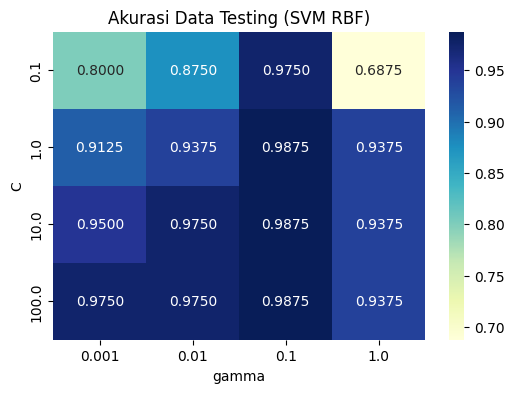

In [9]:
tabel_test = df_rekap.pivot(index='C', columns='gamma', values='Akurasi Test')

plt.figure(figsize=(6, 4))
sns.heatmap(tabel_test, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('Akurasi Data Testing (SVM RBF)')
plt.show()

In [10]:
from sklearn.model_selection import GridSearchCV

# cross-validation hanya memakai data training, data testing tidak disentuh
param_grid = {'svc__C': daftar_C,
              'svc__gamma': daftar_gamma}
grid = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel='rbf')),
                    param_grid, cv=5)
grid.fit(X_train, y_train)

print('Parameter terbaik :', grid.best_params_)
print(f'Akurasi CV terbaik: {grid.best_score_:.4f}')

Parameter terbaik : {'svc__C': 10, 'svc__gamma': 0.1}
Akurasi CV terbaik: 0.9969


---


# **Langkah 7 - Evaluasi Model Terbaik**


---

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

model_terbaik = grid.best_estimator_
y_pred = model_terbaik.predict(X_test)

print(f'Akurasi test: {accuracy_score(y_test, y_pred):.4f}')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Laporan Klasifikasi:\n', classification_report(y_test, y_pred, target_names=['night', 'day']))

Akurasi test: 0.9875
Confusion Matrix:
 [[40  0]
 [ 1 39]]
Laporan Klasifikasi:
               precision    recall  f1-score   support

       night       0.98      1.00      0.99        40
         day       1.00      0.97      0.99        40

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [12]:
ringkasan = pd.DataFrame({
    'Model': ['SVM RBF default (C=1, gamma=scale)', f"SVM RBF tuning {grid.best_params_}"],
    'Akurasi Test': [accuracy_score(y_test, model_default.predict(X_test)),
                     accuracy_score(y_test, y_pred)]
})
ringkasan

,Model,Akurasi Test
0,"SVM RBF default (C=1, gamma=scale)",0.9750
1,"SVM RBF tuning {'svc__C': 10, 'svc__gamma': 0.1}",0.9875


> Model SVM kernel RBF default (C=1, gamma=scale) sudah menghasilkan akurasi testing 0,9875, yaitu hanya 1 dari 80 citra yang salah (citra siang terprediksi malam). Hasil GridSearchCV memilih C=10 dan gamma=0,1 dengan akurasi cross-validation 0,9906 dan akurasi testing yang sama, yaitu 0,9875, jadi tuning pada kasus ini tidak menambah akurasi testing. Dari tabel eksperimen terlihat bahwa gamma yang terlalu besar disertai C kecil membuat model buruk (C=0,1 dan gamma=1 hanya 0,6125), sedangkan gamma terlalu kecil dengan C kecil juga kurang baik (0,85). Kombinasi C=100 dan gamma=0,001 memang mencapai 1,0 pada data testing, tetapi selisihnya hanya 1 citra dan parameter tersebut dilihat dari data testing, sehingga tidak dipilih sebagai model terbaik. Dibandingkan dengan Praktikum 5 yang hanya memakai rata-rata brightness (akurasi testing 0,9), fitur histogram menaikkan akurasi menjadi 0,9875, walaupun pembagian datanya berbeda sehingga perbandingannya hanya sebagai gambaran.